# Tableau and Schur functions

## Math 737 - Lab 4

## SYT and SSYT are classes of objects in Sage. Evaluate the cells below to see how to do some things with SYT. Then in Exercise 2, you'll do similar things with SSYT.

In [7]:
S = StandardTableaux([3,3])

for tab in S:
    display(tab)


In [9]:
StandardTableaux([6,5,4,3,2,1]).cardinality()

1100742656

## Exercise 1a: How many SYT are there of shape $[n,n]$, for $n$ ranging from $1$ to $8$? What numbers are these?

### Hint: Use a 'for' loop. An example of a 'for' loop is given below.


In [12]:
YT_nn=[]
for i in range(1,9):
    print(f"number of 2-by-{i} Young Diagrams: {StandardTableaux([i,i]).cardinality()}")
    YT_nn.append(StandardTableaux([i,i]).cardinality())
print(f"Sequence: {YT_nn}")

number of 2-by-1 Young Diagrams: 1
number of 2-by-2 Young Diagrams: 2
number of 2-by-3 Young Diagrams: 5
number of 2-by-4 Young Diagrams: 14
number of 2-by-5 Young Diagrams: 42
number of 2-by-6 Young Diagrams: 132
number of 2-by-7 Young Diagrams: 429
number of 2-by-8 Young Diagrams: 1430
Sequence: [1, 2, 5, 14, 42, 132, 429, 1430]


These are the the Catalan numbers. C_n = # SYT[n,n]

In [11]:
for n in [1..8]:
    S1 = StandardTableaux([n,n])
    S1.cardinality()
    print("----")

----
----
----
----
----
----
----
----


## Exercise 1b: Use the command SemistandardTableaux to create (not print!) the set of SSYT there are of shape [3,3] (with entries bounded above by 6). How many tableaux are in this set?

## Then use the optional parameter max_entry to create the set of SSYT of shape [3,3] with entries bounded above by 3. Print this smaller set of SSYT.

### (If you need help with this, evaluate the cell below to see the documentation.)

In [15]:
SSYT = SemistandardTableaux([3,3])
SSYT.cardinality()

490

In [17]:
SSYT = SemistandardTableaux([3,3], max_entry=3)
SSYT.cardinality()

10

## Evaluate the cells below to see how to create a SSYT and row-insert numbers into it.

T:


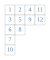

In [22]:
T = SemistandardTableau([[1,2,4,11],[3,5,9,12],[6,8],[7],[10]])
print("T:")
display(T)

T<-(4)


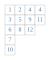

In [27]:
print("T<-(4)")
display(T.schensted_insert(4))

In [20]:
w = T.to_word()
w

word: 10,7,6,8,3,5,9,12,1,2,4,11

T<-


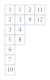

In [28]:
U = SemistandardTableau([[1,2],[3]])
print("T<-")
display(T.bump_multiply(U))

## Exercise 2: Use the above commands to verify the examples of SSYT mutiplication you did in class in two ways: Write a 'for' loop to Schensted insert the letters of the word of the tableau one at a time to create a SSYT. Then, show that you get the same thing when you use bump_multiply.

T:


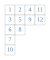

U:


In [71]:
T = SemistandardTableau([[1,2,4,11],[3,5,9,12],[6,8],[7],[10]])
U = SemistandardTableau([[1,2],[3]])
print("T:")
display(T)
print("U:")
display(U)

Loop Result

312


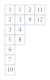

In [73]:
u = U.to_word()
print(u)
TU=T
for l in u:
    TU = TU.schensted_insert(l)

display(TU)

Multiplication result agrees:

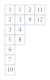

In [68]:
display(T.bump_multiply(U))

## Exercise 3a: Use the command SemistandardSkewTableaux to create (not print!) the set of skew SSYT shape $\lambda / \mu$ with $\lambda = [4,4,2,1]$ and $\mu=[2,1]$ with entries bounded above by 4. How many tableaux are in this set?

## Now create the set of skew SSYT of shape $\lambda / \mu$ with $\lambda = [3,3]$ and $\mu=[2,1]$ with entries bounded above by 3. Use a 'for' loop to print this smaller set of SSYT.

### (Recall, if you need help, you can type a command followed by ? to see the documentation.)


In [104]:
SSskew1 = SemistandardSkewTableaux([[4,4,2,1],[2,1]], max_entry=4)
print(f"# of skew tableau with shape [4,4,2,1]/[2,1]: {SSskew1.cardinality()}")

SSskew2 = SemistandardSkewTableaux([[3,3],[2,1]], max_entry=3)
for tab in SSskew2:
    tab.pp()

# of skew tableau with shape [4,4,2,1]/[2,1]: 664
  .  .  1
  .  1  2
  .  .  1
  .  1  3
  .  .  1
  .  2  2
  .  .  2
  .  1  3
  .  .  1
  .  2  3
  .  .  1
  .  3  3
  .  .  2
  .  2  3
  .  .  2
  .  3  3


## Evaluate the cells below to see how to create a specific skew SSYT and rectify it.

In [111]:
T = SkewTableau([[None,None,2,7],[None,3,5,8],[6,8],[7],[8]])
print("Skew Tableau")
T.pp()
print("Rectified:")
(T.rectify()).pp()


Skew Tableau
  .  .  2  7
  .  3  5  8
  6  8
  7
  8
Rectified:
  2  5  7
  3  8  8
  6
  7
  8


## Exercise 3b: In Exercise 2, you saw how to multiply SSYT. Do one of these same multiplications another way: Use the above commands to create the appropriate skew SSYT so that rectification of that skew SSYT yields the multiplication of the two tableaux.

In [116]:
T = SemistandardTableau([[1,2,4,11],[3,5,9,12],[6,8],[7],[10]])
U = SemistandardTableau([[1,2],[3]])

# build skew tableau by placing U northeast of T
skewTU = SkewTableau([
    [None,None,None, None, 1,2],
    [None,None,None, None, 3],
    [1,2,4,11],
    [3,5,9,12],
    [6,8],
    [7],
    [10]
])
print("Skew tableau:")
skewTU.pp()

print("\nRectification:")
(skewTU.rectify()).pp()

print("\nComputed Product:")
TU.pp()

Skew tableau:
  .  .  .  .  1  2
  .  .  .  .  3
  1  2  4 11
  3  5  9 12
  6  8
  7
 10

Rectification:
  1  1  2 11
  2  3  9 12
  3  4
  5  8
  6
  7
 10

Computed Product:
  1  1  2 11
  2  3  9 12
  3  4
  5  8
  6
  7
 10


## Exercise 4: Is SSYT multiplication commutative? Prove or give a counterexample.


In [119]:
# Exercise 4
T = SemistandardTableau([[1,2,4,11],[3,5,9,12],[6,8],[7],[10]])
U = SemistandardTableau([[1,2],[3]])
print("T:")
T.pp()
print("U:")
U.pp()
print("TU:")
TU.pp()
print("UT:")
UT.pp()
print(f"We can see the two are not the same, but also to computationally verfiy the result of TU=UT is: {TU == UT}")

T:
  1  2  4 11
  3  5  9 12
  6  8
  7
 10
U:
  1  2
  3
TU:
  1  1  2 11
  2  3  9 12
  3  4
  5  8
  6
  7
 10
UT:
  1  1  2  4  9 11
  2  3  5 12
  3  6  8
  7
 10
We can see the two are not the same, but also to computationally verfiy the result of TU=UT is: False


So we see multiplication is not commutative.

## Exercise 5: Evaluate the blocks below to see how to work with the built-in Schur polynomial function in Sage. Verify that you got the same polynomial as we evaluated in class yesterday. Then try changing the parameters to compute other Schur polynomials.

In [135]:
s = SymmetricFunctions(QQ).s()
print(s([2,1]).expand(3))
print("Next: ")
print(s([5,2]).expand(2))
print("Next: ")
print(s([1,1]).expand(6))

x0^2*x1 + x0*x1^2 + x0^2*x2 + 2*x0*x1*x2 + x1^2*x2 + x0*x2^2 + x1*x2^2
Next: 
x0^5*x1^2 + x0^4*x1^3 + x0^3*x1^4 + x0^2*x1^5
Next: 
x0*x1 + x0*x2 + x1*x2 + x0*x3 + x1*x3 + x2*x3 + x0*x4 + x1*x4 + x2*x4 + x3*x4 + x0*x5 + x1*x5 + x2*x5 + x3*x5 + x4*x5


## Exercise 6 (if time): Play with the built-in tableaux functions to find some fun things to do with tableaux. Pick your favorite, demonstrate using it, and write a sentence to say what it does.

In [128]:
A = SemistandardTableau([[1,2,3,4],[5,6,7],[8,8],[35]])
B = SemistandardTableau([[1,2],[3,4]])

# build skew tableau by placing U northeast of T
skewAB = SkewTableau([
    [None,None,None, None, 1,2],
    [None,None,None, None, 3,4],
    [1,2,3,4],
    [5,6,7],
    [8,8],
    [35]
])
print("Skew tableau:")
skewAB.pp()

print("\nRectification:")
(skewAB.rectify()).pp()

print("\nProduct:")
(A.bump_multiply(B)).pp()


Skew tableau:
  .  .  .  .  1  2
  .  .  .  .  3  4
  1  2  3  4
  5  6  7
  8  8
 35

Rectification:
  1  1  2  3  4
  2  3  7
  4  6
  5  8
  8
 35

Product:
  1  1  2  3  4
  2  3  7
  4  6
  5  8
  8
 35


I like the rectification stuff